## Librerias

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import random


from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

## seccion 1

### Data sets

In [69]:
df = pd.read_csv("../data/movies_2026.csv", encoding="latin1")
print("Dimensiones del dataset:", df.shape)
df.head()

variables_rules = ['genres','budget','revenue','popularity','voteAvg','releaseYear']
df_rules = df[variables_rules].copy()

Dimensiones del dataset: (19883, 28)


In [70]:
df.columns

Index(['id', 'budget', 'genres', 'homePage', 'productionCompany',
       'productionCompanyCountry', 'productionCountry', 'revenue', 'runtime',
       'video', 'director', 'actors', 'actorsPopularity', 'actorsCharacter',
       'originalTitle', 'title', 'originalLanguage', 'popularity',
       'releaseDate', 'voteAvg', 'voteCount', 'genresAmount',
       'productionCoAmount', 'productionCountriesAmount', 'actorsAmount',
       'castWomenAmount', 'castMenAmount', 'releaseYear'],
      dtype='object')

### variables numericas relevantes

In [71]:
variables_cluster = [
    'popularity',
    'budget',
    'revenue',
    'runtime',
    'voteAvg',
    'voteCount',
    'actorsPopularity',
    'actorsAmount',
    'genresAmount',
    'productionCountriesAmount',
    'castWomenAmount',
    'castMenAmount',
    'releaseYear'
]

df_cluster = df[variables_cluster].copy()

In [72]:
df_cluster.dtypes

popularity                   float64
budget                       float64
revenue                      float64
runtime                        int64
voteAvg                      float64
voteCount                      int64
actorsPopularity              object
actorsAmount                   int64
genresAmount                   int64
productionCountriesAmount      int64
castWomenAmount              float64
castMenAmount                float64
releaseYear                  float64
dtype: object

In [73]:
df_cluster = df_cluster.apply(pd.to_numeric, errors='coerce')
df_cluster = df_cluster.dropna()

print("Dimensiones después de limpiar:", df_cluster.shape)
df_cluster.dtypes

Dimensiones después de limpiar: (1075, 13)


popularity                   float64
budget                       float64
revenue                      float64
runtime                        int64
voteAvg                      float64
voteCount                      int64
actorsPopularity             float64
actorsAmount                   int64
genresAmount                   int64
productionCountriesAmount      int64
castWomenAmount              float64
castMenAmount                float64
releaseYear                  float64
dtype: object

In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

X_scaled[:5]

array([[-0.15839188, -0.04835959, -0.03054557,  0.39928389, -0.4522403 ,
        -0.15152811, -0.23779386,  0.0749181 , -1.32713252,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.14718048, -0.04835959, -0.03054557, -0.64835717, -0.4522403 ,
        -0.15152811, -0.21757567,  0.0749181 ,  2.29079002,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.15913614, -0.03677201, -0.03054557, -0.64835717, -0.4522403 ,
        -0.15152811, -0.22971788,  0.0749181 , -0.12115834,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.13954785, -0.04835959, -0.03054557, -0.5086717 , -0.4522403 ,
        -0.15152811, -0.23779386,  0.0749181 , -0.12115834,  0.63677232,
        -0.41509153, -0.07265112,  0.49775914],
       [-0.1625249 , -0.04835959, -0.03054557,  1.3538013 , -0.4522403 ,
        -0.15152811,  0.11788815,  0.0749181 , -0.12115834,  0.63677232,
        -0.41509153, -0.07263056,  0.49775914]])

### Analisis de la tendencia al agrupamiento

In [75]:
def hopkins(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    ujd = []
    wjd = []

    for _ in range(m):
        rand_point = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), d)
        u_dist, _ = nbrs.kneighbors([rand_point], 2)
        ujd.append(u_dist[0][1])

        rand_index = np.random.randint(0, n)
        w_dist, _ = nbrs.kneighbors([X[rand_index]], 2)
        wjd.append(w_dist[0][1])

    H = sum(ujd) / (sum(ujd) + sum(wjd))
    return H

In [76]:
hopkins_value = hopkins(X_scaled)
print("Hopkins statistic:", hopkins_value)

Hopkins statistic: 0.9828503487528668


### Número Óptimo de Clusters (metodo codo)

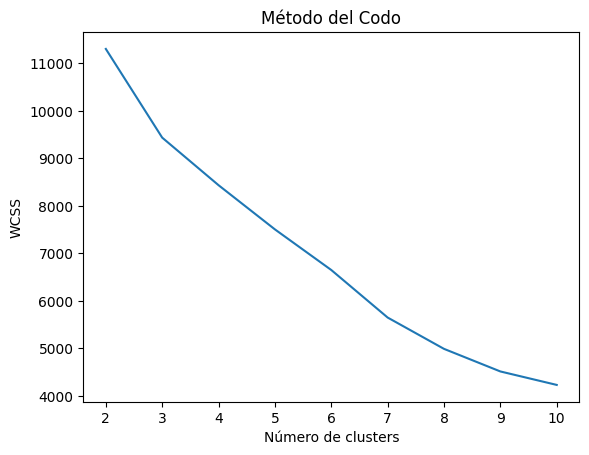

In [77]:
wcss = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2, 11), wcss)
plt.xlabel("Número de clusters")
plt.ylabel("WCSS")
plt.title("Método del Codo")
plt.show()

### K-Means (k=7)

In [78]:
k_optimo = 7

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

df_cluster['cluster_kmeans'] = clusters_kmeans

df_cluster.head()

,popularity,budget,revenue,runtime,voteAvg,voteCount,actorsPopularity,actorsAmount,genresAmount,productionCountriesAmount,castWomenAmount,castMenAmount,releaseYear,cluster_kmeans
13,0.0404,0.0,0.0,45,0.0,0,0.0071,1,0,1,0.0,0.0,2026.0,2
18,0.1112,0.0,0.0,0,0.0,0,0.0429,1,3,1,0.0,0.0,2026.0,2
23,0.0357,300.0,0.0,0,0.0,0,0.0214,1,1,1,0.0,0.0,2026.0,2
26,0.1594,0.0,0.0,6,0.0,0,0.0071,1,1,1,0.0,0.0,2026.0,2
36,0.0143,0.0,0.0,86,0.0,0,0.6369,1,1,1,0.0,1.0,2026.0,2


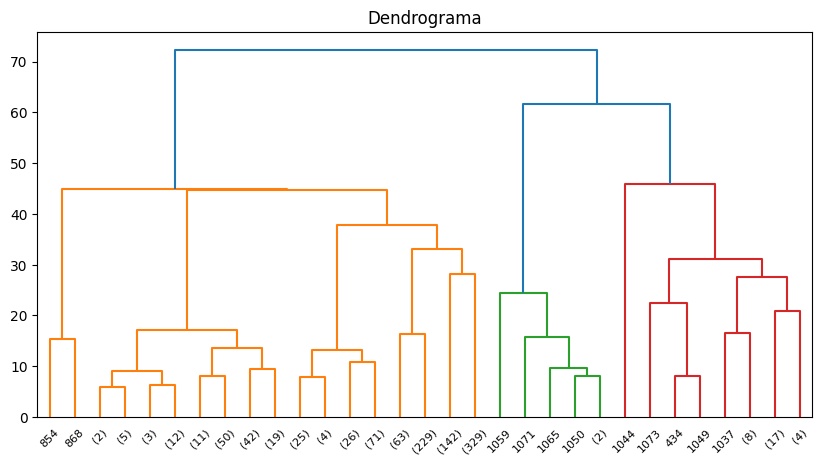

In [79]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrograma")
plt.show()

clusters_hier = fcluster(Z, k_optimo, criterion='maxclust')
df_cluster['cluster_hier'] = clusters_hier

### Calidad del Agrupamiento

In [80]:
sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)
sil_hier = silhouette_score(X_scaled, clusters_hier)

print("Silhouette KMeans:", sil_kmeans)
print("Silhouette Jerárquico:", sil_hier)

Silhouette KMeans: 0.27133049343822824
Silhouette Jerárquico: 0.35910519639436844


### interpretacion (clusters)

#### tamaño 

In [81]:
df_cluster['cluster_hier'].value_counts().sort_index()

cluster_hier
1      2
2    144
3    126
4    763
5      6
6     33
7      1
Name: count, dtype: int64

##### medias

In [82]:
df_cluster.groupby('cluster_hier').mean()

,popularity,budget,revenue,runtime,voteAvg,voteCount,actorsPopularity,actorsAmount,genresAmount,productionCountriesAmount,castWomenAmount,castMenAmount,releaseYear,cluster_kmeans
cluster_hier,,,,,,,,,,,,,,
1,0.125550,572277.000000,0.000000e+00,84.000000,0.000000,0.000000,0.595750,1.0,1.500000,3.000000,0.000000,0.500000,2025.000000,5.000000
2,0.172450,261.784722,2.083333e-01,34.513889,1.314347,0.298611,0.524724,1.0,1.097222,0.583333,1.000000,0.000000,2025.173611,6.000000
3,0.291223,107.015873,1.587302e-01,28.706349,7.783135,2.420635,0.490006,1.0,1.253968,0.603175,0.000000,0.539683,2025.230159,1.206349
4,0.088755,195.984273,2.257929e+01,23.465269,0.032372,0.027523,0.162943,1.0,1.053735,0.583224,0.000000,0.342071,2025.290957,1.072084
5,37.168167,100.000000,0.000000e+00,163.000000,8.066667,24.833333,3.509667,0.0,1.000000,1.000000,0.666667,633082.500000,2015.666667,3.000000
6,22.680585,1.515152,0.000000e+00,67.272727,6.991333,86.000000,5.100742,1.0,1.606061,1.242424,0.272727,0.484848,2016.818182,1.242424
7,17.727000,0.000000,1.666108e+07,81.000000,6.900000,103.000000,8.069000,1.0,1.000000,1.000000,1.000000,0.000000,2015.000000,4.000000


In [83]:
#budget
df_cluster.groupby('cluster_hier')['budget'].mean().sort_values()


cluster_hier
7         0.000000
6         1.515152
5       100.000000
3       107.015873
4       195.984273
2       261.784722
1    572277.000000
Name: budget, dtype: float64

In [84]:
#revenue
df_cluster.groupby('cluster_hier')['revenue'].mean().sort_values()


cluster_hier
1    0.000000e+00
5    0.000000e+00
6    0.000000e+00
3    1.587302e-01
2    2.083333e-01
4    2.257929e+01
7    1.666108e+07
Name: revenue, dtype: float64

In [85]:
#popularity
df_cluster.groupby('cluster_hier')['popularity'].mean().sort_values()

cluster_hier
4     0.088755
1     0.125550
2     0.172450
3     0.291223
7    17.727000
6    22.680585
5    37.168167
Name: popularity, dtype: float64

### Reglas de asociacion 

In [86]:

def discretizar_3_niveles_robusta(serie, etiquetas):
    serie = pd.to_numeric(serie, errors='coerce')
    q1 = serie.quantile(0.33)
    q2 = serie.quantile(0.66)

    
    if q1 == q2:
        
        q = serie.quantile(0.5)
        if q == serie.min() or q == serie.max():
            return pd.Series([etiquetas[0]] * len(serie), index=serie.index)  # todo "bajo"
        return pd.cut(serie, bins=[-np.inf, q, np.inf], labels=[etiquetas[0], etiquetas[-1]])

    return pd.cut(serie, bins=[-np.inf, q1, q2, np.inf], labels=etiquetas)




In [87]:
for col in ['budget','revenue','popularity','voteAvg','releaseYear']:
    df_rules[col] = (
        df_rules[col].astype(str)
        .str.replace(',', '', regex=False)
        .replace('nan', np.nan)
    )
    df_rules[col] = pd.to_numeric(df_rules[col], errors='coerce')

df_rules = df_rules.dropna()


def discretizar_3_niveles_robusta(serie, etiquetas):
    serie = pd.to_numeric(serie, errors='coerce')
    q1 = serie.quantile(0.33)
    q2 = serie.quantile(0.66)

    if q1 == q2:
        q = serie.quantile(0.5)
        if q == serie.min() or q == serie.max():
            return pd.Series([etiquetas[0]] * len(serie), index=serie.index)
        return pd.cut(serie, bins=[-np.inf, q, np.inf], labels=[etiquetas[0], etiquetas[-1]])

    return pd.cut(serie, bins=[-np.inf, q1, q2, np.inf], labels=etiquetas)

df_rules['budget_cat']      = discretizar_3_niveles_robusta(df_rules['budget'], ['bajo','medio','alto'])
df_rules['revenue_cat']     = discretizar_3_niveles_robusta(df_rules['revenue'], ['bajo','medio','alto'])
df_rules['popularity_cat']  = discretizar_3_niveles_robusta(df_rules['popularity'], ['bajo','medio','alto'])
df_rules['voteAvg_cat']     = discretizar_3_niveles_robusta(df_rules['voteAvg'], ['bajo','medio','alto'])
df_rules['releaseYear_cat'] = discretizar_3_niveles_robusta(df_rules['releaseYear'], ['antiguo','medio','reciente'])


print(df_rules[['budget','budget_cat']].head())
print(df_rules['budget_cat'].value_counts(dropna=False))

   budget budget_cat
0     0.0       bajo
1     0.0       bajo
2     0.0       bajo
3     0.0       bajo
4     0.0       bajo
budget_cat
bajo     11439
alto      6092
medio      386
Name: count, dtype: int64


In [90]:
def split_generos(x):
    if pd.isna(x):
        return []
    s = str(x)
    if "|" in s:
        return [g.strip() for g in s.split("|")]
    elif "," in s:
        return [g.strip() for g in s.split(",")]
    else:
        return [s.strip()]

df_rules['genres_list'] = df_rules['genres'].apply(split_generos)

df_rules['items'] = df_rules.apply(lambda r: (
    [f"genre={g}" for g in r['genres_list']] +
    [f"budget={r['budget_cat']}",
     f"revenue={r['revenue_cat']}",
     f"popularity={r['popularity_cat']}",
     f"voteAvg={r['voteAvg_cat']}",
     f"releaseYear={r['releaseYear_cat']}"]
), axis=1)

transactions = df_rules['items'].tolist()

te = TransactionEncoder()
df_encoded = pd.DataFrame(
    te.fit(transactions).transform(transactions),
    columns=te.columns_
)

df_encoded.head()

,budget=alto,budget=bajo,budget=medio,genre=Action,genre=Adventure,genre=Animation,genre=Comedy,genre=Crime,genre=Documentary,genre=Drama,...,popularity=alto,popularity=bajo,popularity=medio,releaseYear=antiguo,releaseYear=medio,releaseYear=reciente,revenue=bajo,voteAvg=alto,voteAvg=bajo,voteAvg=medio
0,False,True,False,False,False,False,False,True,False,True,...,False,True,False,False,False,True,True,False,True,False
1,False,True,False,False,False,True,False,False,False,False,...,False,True,False,False,False,True,True,False,True,False
2,False,True,False,False,False,True,False,False,False,False,...,False,True,False,False,False,True,True,False,True,False
3,False,True,False,False,False,False,False,False,True,False,...,False,True,False,False,False,True,True,False,True,False
4,False,True,False,False,False,True,False,False,False,False,...,False,True,False,False,False,True,True,False,True,False
